### Machines and Processes - Laboratory
### Part: Hydraulic Turbomachinery
# Experimental Measurement of Fan Curves

version: V2026-02

Jannis Malek (jannis.malek@kit.edu)<br>
Vivaswat Kumar (vivaswat.kumar@kit.edu)<br>
Dr.-Ing. Balazs Pritz (balazs.pritz@kit.edu)<br>

---

# 0. Before we start

1. This notebook guides you through the post-processing of the provided fan measurements. </br>
   You should also use it to write your lab report.
1. Please go step by step (cell by cell) through the notebook.
    1. You has to execute a cell by click on <span> &#9654; </span>  or use the shortcut SHIFT + ENTER
    1. Cells are Code, Markdown or Raw. If you want to reedit a markdown cell, you should double click on it.
    1. Do not use # in markdown cells. # is used for comments in code cells.
1. Where `#TODO` is written, **you must complete** the code!
1. Throughout the notebook there are several sections that should be completed for the lab report. Please complete them as they will be checked by the tutor.
1. Some cells are marked with formula: Please enter the required formula for the next calculation here. These formulas will be checked by the tutor.
1. When you went through all code successfully, then start at the beginning and add your measurements.
1. At the end of this notebook, there is an assesment and some questions which you must answer. These sections will be checked by the tutor.
1. Finally, use in the menu File / Print... / Save as PDF and e-mail the pdf file to your tutor.

# Name of participants

Okello Patrick Leon; uyslf@student.kit.edu

Aditya Jyotis; unzuz@student.kit.edu

Anurag Mishra; anurag.mishra@stduent.kit.edu

Krishnan Castillo Lopez; uhtlf@student.kit.edu

# Upload relevant data/files

Make sure to upload the zip-archive "lab_course_data.zip". The following line unpacks it:

In [166]:
import zipfile
with zipfile.ZipFile('lab_course_data.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

Import assertion to verify your implemented equations.

In [167]:
import assertion

## **Test rig**
The below figure illustrates the principle setup of the fan test rigs. Think about what data need to be measured. Note down every measured data in a spreadsheet or a csv-file. Note, that you will need to provide the relevant measurements in a **CSV file** in the end, because you will process them with this notebook.

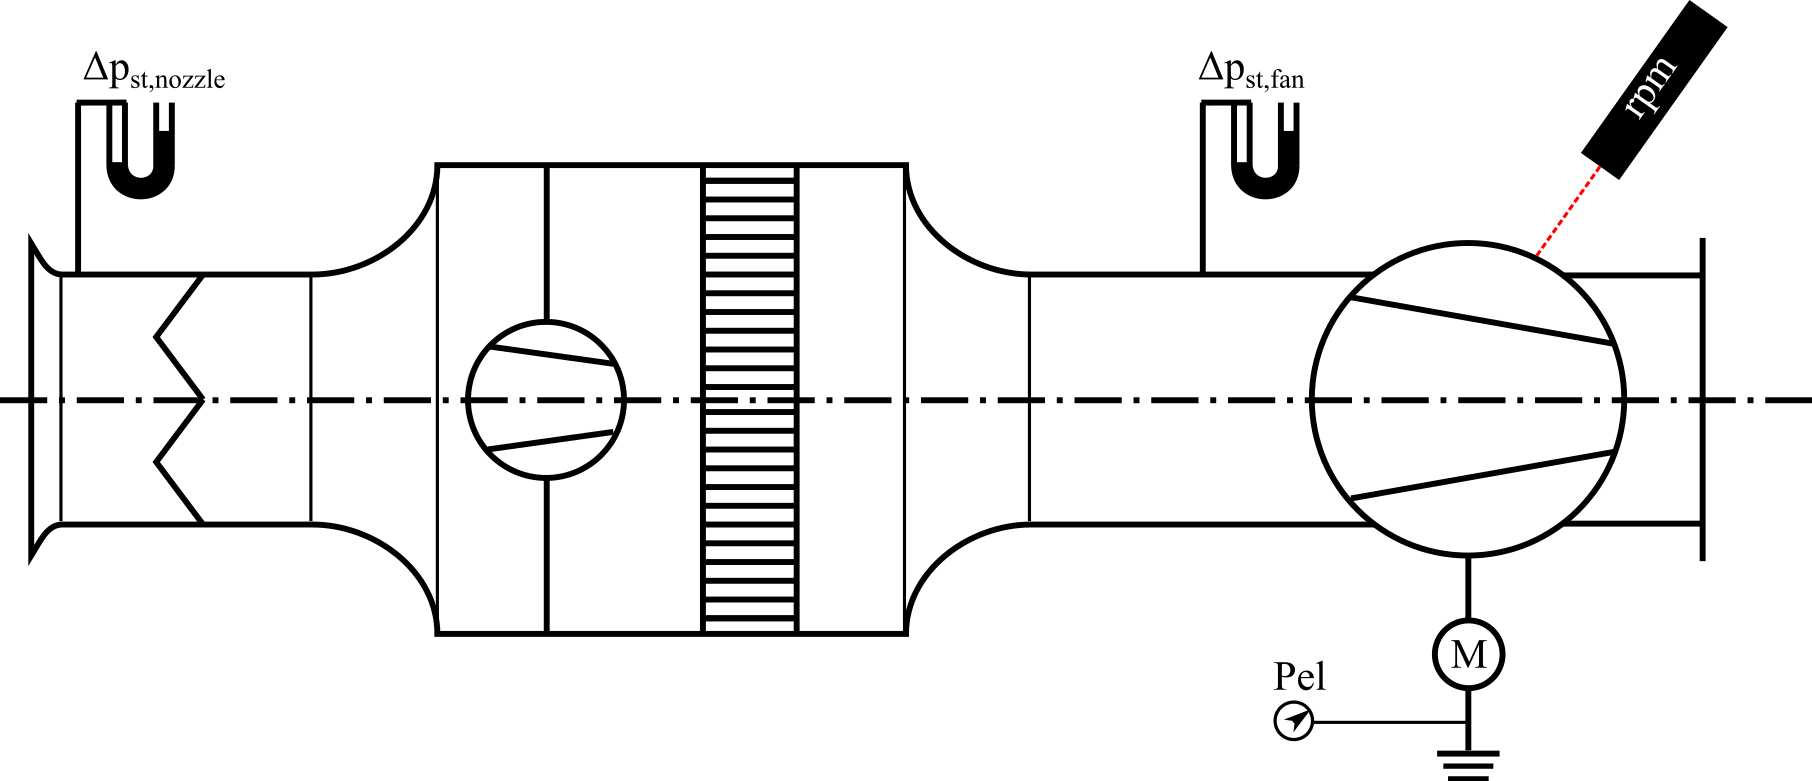

In [168]:
from IPython.display import Image
Image('testrig.png')

### Description of test rig - Pruefstandsbeschreibung

The test rig is an open air-flow test bench. Air enters through a calibrated inlet nozzle, passes an auxiliary fan and a flow straightener, and then reaches the fan under investigation. A throttle before the auxiliary fan changes the system resistance and therefore the operating point. Betz manometers measure the nozzle pressure difference and the static pressure related to the test fan. The electrical input power and rotational speed of the test fan are measured as well.

### Description of measurement procedure - Messablauf

1. Measure room temperature, relative humidity and ambient pressure.
2. Set a throttle position to 0
3. Set the Auxiliary Fan power to 100.
4. Wait until the operating point is steady.
5. Record nozzle pressure difference, fan static-pressure difference, test-fan speed and electrical power.
6. Repeat for many throttle positions so that the entire accessible characteristic curve is covered.
7. Convert and evaluate all points in this notebook, then use the affinity laws to refer them to one common speed.
8. Repeat the steps but with the auxiliary fan off.

### Used measurement devices - Verwendete Messgeraete

- **Betz manometer:** pressure differences in mm water column (mmWC). The height difference represents hydrostatic pressure, $\Delta p=\rho_w g h$.
- **Optical tachometer:** rotational speed in rpm; it detects a reflective mark on the rotating shaft/impeller.
- **Electrical power meter:** electrical input power in W.
- **Thermometer, hygrometer and barometer:** temperature, relative humidity and ambient pressure for calculation of air density.

# 1. Quick Introduction into Python

Declaring variables: Let's say, we want to store a number in a variable:

In [169]:
my_number = 4.3

Variables **must not** start with a number. Make sure to use meaningful names for the variables, so that everybody understands your code.

In Python, there is no need to declare the type before assigning the value: 4.3 was of type float. (There are also other data types besides floats like integer, character.)

In [170]:
an_integer = 4
a_string = 'hello'
another_string = "hi"  # you can use either '' or "" to indicate a string
a_list_of_variables = [1.23, an_integer, my_number, 'test']  # you can put anything into a list
a_dictionary = {'key1': 5.66, 'name': 'Matthias'}  # key-value pairs are stored in dictionaries

# print a variable:
print(a_list_of_variables)

[1.23, 4, 4.3, 'test']


**Reading data from text files:**

In our lab course, we will need to read data from a text file. The package `pandas` helps us with it. We import it and select an alias for it:

In [171]:
import pandas as pd

The method `read_csv` requires a file path ('Fan_C.csv'). We can specify more parameters, in our case, we also tell the method that the columns in the file are separated with a *tab* (\\t). With the option *decimal* you can tell pandas if your numbers use decimal point or comma.

In [172]:
my_dataframe = pd.read_csv('Fan_C.csv', delimiter=',', decimal='.')
my_dataframe.head()  # prints only the first few rows of the file, including the header

,throttle,nozzle_static_p,fan_static_p,Power,fan_speed
0,1.00,27.05,14.4,137,2536
1,0.80,26.60,14.7,136,2533
2,0.60,24.15,15.7,130,2569
3,0.48,23.30,16.9,132,2558
4,0.37,21.20,19.0,132,2542


The data is stored in a so-called "data frame", where the first column is generated additionally with the index of rows. To access the column data, do the following:

In [173]:
print(my_dataframe.columns)
my_dataframe['nozzle_static_p']
# If you wonder how to find out all column names without the above head() statement:

my_dataframe['throttle']

Index(['throttle', 'nozzle_static_p', 'fan_static_p', 'Power', 'fan_speed'], dtype='str')


0     1.00
1     0.80
2     0.60
3     0.48
4     0.37
5     0.20
6     0.11
7     1.00
8     0.91
9     0.80
10    0.63
11    0.48
12    0.31
13    0.19
14    0.10
15    0.40
Name: throttle, dtype: float64

**Writing a function**

For computations that are needed to be run multiple times, we can just write a function and call it.
Note, that python requires lines that belong together (logically) to be indented by Tab/4 spaces:

In [174]:
def my_function(a, b, c=5):
    d = a+b
    return d*c  # this returns the value

# call the function. Note the possibilities how to pass the arguments:
res_1 = my_function(4.6, 10)
res_2 = my_function(4.6, b=10, c=20.5)
res_3 = my_function(b=4.6, a=10, c=20.5)
print('Results of function "my_function": ' + str(res_1) + ', ' + str(res_2) + ' and ' + str(res_3))

Results of function "my_function": 73.0, 299.3 and 299.3


## Recording data

Record the data and store it in a CSV file. A CSV file is a comma-separated file (the separator/delimiter can be anything, e.g. a space or a tab, ...). Excel, for instance, can read and output such files.

Your file should look something like this (here the delimiter is ;):

```
Pressure1;Pressure2;Revspeed;Power
13.2;20.8;1423;120.0
12.8;21.4;1458;118.5
14.1;18.2;1521;119.2
...
```

# 2. Preparation

## 2.1 Reading in data

If you want to know a bit more about reading data, check out the tutorial-notebook `reading_data.ipynb`.

We use the (very popular) package `pandas` to read from the csv-file. We choose to select an alias for it, namely `pd` (this is commonly done. You will see imports like this more often).

We assume that the data is located in the same folder as the notebook (this file). From ILIAS you can download "Fan_C.csv" and "Fan_A.csv". Your own measurement(s) should have a different name.

This notebook evaluates the data from ilias. You can first go through it and add the respective lines to also read and process your own measurements afterwards.

We call the function `read_csv` from the package. It returns the object of type `pandas.DataFrame`.

In [175]:
import pandas as pd

df2 = pd.read_csv('Fan_C.csv', delimiter=',', decimal='.')
df1 = pd.read_csv('Fan_A.csv', delimiter=',', decimal='.')

# show the column (names) of the "dataframe 1" (df1):
df1.columns

Index(['nozzle_static_p', 'fan_static_p', 'fan_speed', 'Power'], dtype='str')

In [176]:
# show the content of "dataframe 1" (df1):
df1

,nozzle_static_p,fan_static_p,fan_speed,Power
0,21.8,7.4,1421.0,108.9
1,21.5,7.3,1420.0,108.6
2,21.4,7.4,1420.0,109.3
3,21.4,7.5,1420.0,109.4
4,20.4,7.7,1421.0,109.2
5,18.2,8.6,1422.0,108.5
6,7.4,9.0,1438.0,100.8
7,5.1,8.5,1446.0,97.8
8,4.8,8.6,1447.0,97.8
9,4.8,8.5,1446.0,97.0


In [177]:
df2

,throttle,nozzle_static_p,fan_static_p,Power,fan_speed
0,1.00,27.05,14.40,137,2536
1,0.80,26.60,14.70,136,2533
2,0.60,24.15,15.70,130,2569
3,0.48,23.30,16.90,132,2558
4,0.37,21.20,19.00,132,2542
5,0.20,16.70,23.25,139,2514
6,0.11,13.40,26.75,142,2496
7,1.00,15.50,24.60,143,2511
8,0.91,15.40,24.90,143,2510
9,0.80,15.70,24.50,143,2512


## 2.2 Define and compute constants and properties
In order to compute the operation points in a later section, we need to define and compute some constants, such as the cross sectional areas A or the shape factor $\alpha$ (deutsch: Formfaktor):

For a circular cross-section,

\begin{equation}
A=\frac{\pi D^2}{4}.
\end{equation}

Thus, $A_{nozzle}=\pi D_{nozzle}^2/4$ and $A_{fan}=\pi D_{fan}^2/4$.

In [178]:
import numpy as np
print(np.pi)

eta_motor = 0.8

# Geometry of the two provided reference test rigs.
# Check the labels on your actual rig and replace these values if your lab setup differs.
D_nozzle_1 = 0.134  # m
D_fan_1 = 0.250     # m
alpha_1 = 0.98
A_nozzle_1 = np.pi * D_nozzle_1**2 / 4
A_fan_1 = np.pi * D_fan_1**2 / 4

D_nozzle_2 = 0.131  # m
D_fan_2 = 0.250     # m
alpha_2 = 0.98
A_nozzle_2 = np.pi * D_nozzle_2**2 / 4
A_fan_2 = np.pi * D_fan_2**2 / 4

print('Areas fan 1:', A_nozzle_1, A_fan_1)
print('Areas fan 2:', A_nozzle_2, A_fan_2)

3.141592653589793
Areas fan 1: 0.014102609421964583 0.04908738521234052
Areas fan 2: 0.013478217882063612 0.04908738521234052


## 2.3 Compute the density
From the relative humidity, temperature and ambient pressure you can compute the air density:

\begin{equation}
\rho=\frac{p_{amb}}{R_f \cdot T} ~~ ,
\end{equation}
where
\begin{equation}
R_f = \frac{R_d}{1-\varphi \cdot v_p/p_{amb} \cdot (1-R_v/R_d)} ~~ .
\end{equation}



In [179]:
# some constants:
Rd = 287.1  # specific gas constant for dry air: J/kg/K
Rv = 461.5  # specific gas constant for water vapor: J/kg/K
VAPOR_PRESSURE = 2300  # vapor pressure [Pa] at around room temperature

# EXAMPLE conditions used to reproduce the supplied reference curves.
# Replace these three values with the values measured during your lab.
T_room = 296.90  # K = 25 degC
phi = 0.40       # relative humidity as a fraction, not percent
p_amb = 101020.0 # Pa

Rf = Rd / (1 - phi * VAPOR_PRESSURE / p_amb * (1 - Rv / Rd))
rho = p_amb / (Rf * T_room)

print(f'R_f = {Rf:.3f} J/(kg K)')
print(f'rho = {rho:.4f} kg/m^3')
assertion.assert_density(rho)

R_f = 285.520 J/(kg K)
rho = 1.1917 kg/m^3
The density of air seems to be correct: 1.191681 kg/m^3. Well done!


## 2.4 Computing the static pressure

You did not measure pressure in `Pa` (pascal) but in units of `mmWC` (millimeter-water-column). Let's write a function to convert the values with unit `mmWC` into `Pa`:

A liquid column produces the hydrostatic pressure

\begin{equation}
\Delta p=\rho_w g h.
\end{equation}

Because the measured height is entered in millimetres,

\begin{equation}
\Delta p[\mathrm{Pa}]=h[\mathrm{mmWC}]\cdot \frac{1}{1000}\cdot \rho_w g.
\end{equation}

For water with $\rho_w\approx1000\,\mathrm{kg/m^3}$, $1\,\mathrm{mmWC}\approx9.81\,\mathrm{Pa}$.

In [180]:
def mmWC_to_Pa(values:pd.Series, density=1000.0, gravity=9.81):
    """Convert a pressure-column height in mmWC into pressure in Pa."""
    return values / 1000.0 * density * gravity

assertion.assert_mmWC_to_Pa(mmWC_to_Pa)

Your implementation gives correct results. Well done.


In [181]:
# Example: convert the measured static pressure values of fan 1.
dp_nozzle1_measured = df1['nozzle_static_p']
dp_nozzle2_measured = df2['nozzle_static_p']
dp_fan_1_measured = df1['fan_static_p']
dp_fan_2_measured = df2['fan_static_p']
dp_fan = mmWC_to_Pa(dp_fan_1_measured)
dp_fan.head()

0    72.594
1    71.613
2    72.594
3    73.575
4    75.537
Name: fan_static_p, dtype: float64

## 2.5 Plot the measured data

Now, it's time to see what we measured. Let's plot the data in a single or in multiple plots. You decide!

If you are stuck, check out the tutorial concerning `plotting`.

The plotting-package is called `matplotlib`. From it, we need the module `pyplot`. Again, we give it a nice alias:

In [182]:
import matplotlib.pyplot as plt

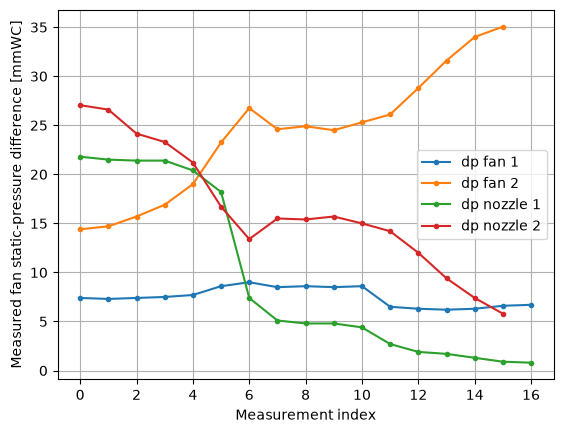

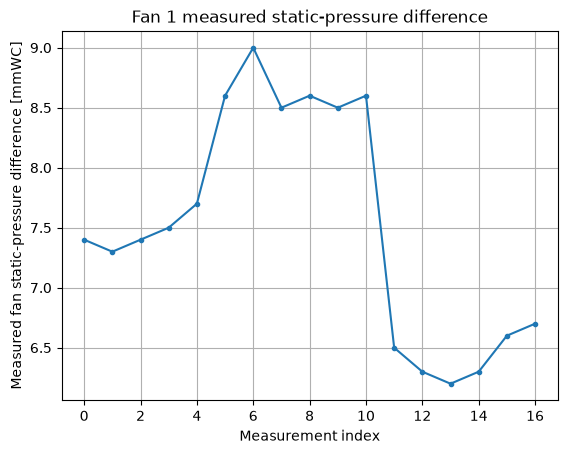

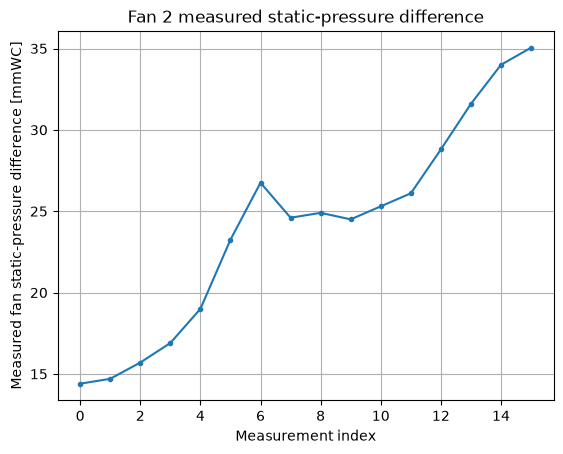

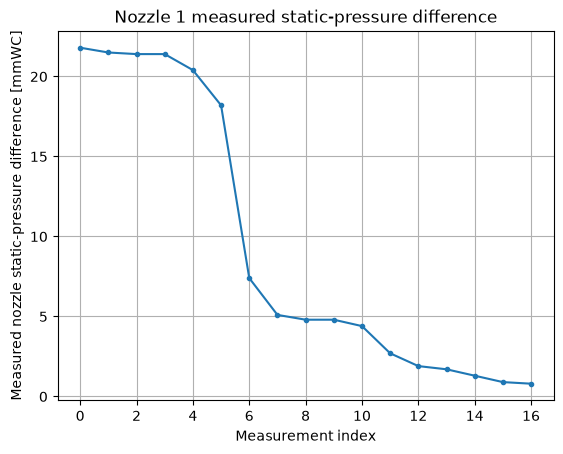

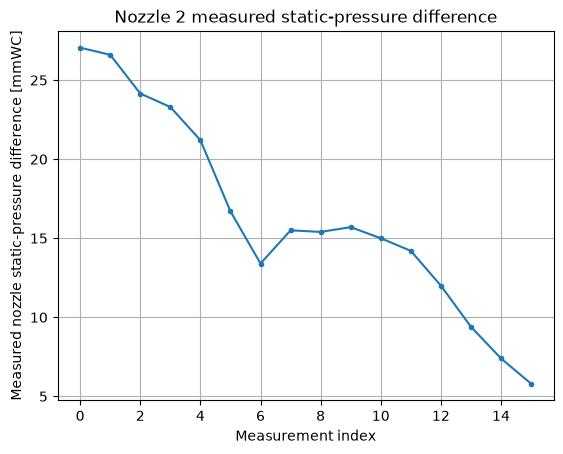

In [183]:
plt.figure()
plt.plot(dp_fan_1_measured, '.-')
plt.plot(dp_fan_2_measured, '.-')
plt.plot(dp_nozzle1_measured, '.-')
plt.plot(dp_nozzle2_measured, '.-')
plt.legend(['dp fan 1','dp fan 2','dp nozzle 1', 'dp nozzle 2'])
plt.xlabel('Measurement index')
plt.ylabel('Measured fan static-pressure difference [mmWC]')
plt.grid(True)
plt.savefig('dp_fan_1_measured.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.plot(dp_fan_1_measured, '.-')
plt.title('Fan 1 measured static-pressure difference')
plt.xlabel('Measurement index')
plt.ylabel('Measured fan static-pressure difference [mmWC]')
plt.grid(True)
plt.savefig('dp_fan_1_measured.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.plot(dp_fan_2_measured, '.-')
plt.title('Fan 2 measured static-pressure difference')
plt.xlabel('Measurement index')
plt.ylabel('Measured fan static-pressure difference [mmWC]')
plt.grid(True)
plt.savefig('dp_fan_2_measured.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.plot(dp_nozzle1_measured, '.-')
plt.title('Nozzle 1 measured static-pressure difference')
plt.xlabel('Measurement index')
plt.ylabel('Measured nozzle static-pressure difference [mmWC]')
plt.grid(True)
plt.savefig('dp_nozzle1_measured.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.plot(dp_nozzle2_measured, '.-')
plt.title('Nozzle 2 measured static-pressure difference')
plt.xlabel('Measurement index')
plt.ylabel('Measured nozzle static-pressure difference [mmWC]')
plt.grid(True)
plt.savefig('dp_nozzle2_measured.png', dpi=300, bbox_inches='tight')
plt.show()



## 2.6 Computing the volume flow rate

It's time to write another function. In order to plot the fan curve in the end, we first need a function that computes the volume flow rate from the measured pressure at the inlet nozzle:

Apply Bernoulli between the still ambient air and the nozzle measuring section. With the nozzle coefficient $\alpha$,

\begin{equation}
\dot V=\alpha A_{nozzle}\sqrt{\frac{2\Delta p_{nozzle}}{\rho_{air}}}.
\end{equation}

The square-root dependence is important: four times the nozzle pressure difference corresponds to twice the volume flow rate.

In [184]:
def calc_vdot(dp_nozzle, area_nozzle, density_air, alpha=0.98):
    """Calculate volume flow rate [m^3/s] from nozzle pressure difference [Pa]."""
    dp_nonnegative = np.maximum(dp_nozzle, 0.0)
    return alpha * area_nozzle * np.sqrt(2.0 * dp_nonnegative / density_air)

## 2.7 Defining the Affinity-functions
Our goal is to draw the fan curve for a single revolution speed $n_i$. For this we need to apply the affinity laws on all measured operation points to compute the respective operation point for $n_i$

<!-- For the same geometrical fan and approximately constant density,

\begin{align}
\frac{\dot V_2}{\dot V_1}&=\frac{n_2}{n_1},\\
\frac{\Delta p_2}{\Delta p_1}&=\left(\frac{n_2}{n_1}\right)^2,\\
\frac{P_2}{P_1}&=\left(\frac{n_2}{n_1}\right)^3.
\end{align} -->

$$\frac{\dot{V}_2}{\dot{V}_1} = \frac{D_2^3}{D_1^3} \textcolor{red}{\frac{n_2}{n_1}}$$
$$\frac{y_2}{y_1} = \frac{H_2}{H_1} = \frac{D_2^2}{D_1^2} \textcolor{red}{\frac{n_2^2}{n_1^2}} \quad \text{hence} \quad \frac{\Delta p_2}{\Delta p_1} = \frac{\rho_2}{\rho_1} \frac{D_2^2}{D_1^2} \textcolor{red}{\frac{n_2^2}{n_1^2}}$$
$$\frac{P_2}{P_1} = \frac{\rho_2}{\rho_1} \frac{D_2^5}{D_1^5} \textcolor{red}{\frac{n_2^3}{n_1^3}}$$


The efficiency remains approximately unchanged at corresponding, dynamically similar operating points.

In [185]:
def affi_vdot(vdot, n_old, n_new):
    return vdot * (n_new / n_old)

def affi_pressure(pressure, n_old, n_new):
    return pressure * (n_new / n_old)**2

def affi_power(power, n_old, n_new):
    return power * (n_new / n_old)**3

# 3. Computing the operation points

It's time to compute the operation points.

## 3.1 First compute the pressures using your function `mmWC_to_Pa`:

In [186]:
dp_nozzle_1 = mmWC_to_Pa(df1['nozzle_static_p'])
dp_nozzle_2 = mmWC_to_Pa(df2['nozzle_static_p'])
dp_fan_1 = mmWC_to_Pa(df1['fan_static_p'])
dp_fan_2 = mmWC_to_Pa(df2['fan_static_p'])

## 3.2 Compute the volume flow rates:

In [187]:
vfr_1 = calc_vdot(dp_nozzle_1, A_nozzle_1, rho, alpha_1)
vfr_2 = calc_vdot(dp_nozzle_2, A_nozzle_2, rho, alpha_2)

## 3.3 Compute the total pressure increase (fan pressure):
Hint: Have a look into the lecture notes ("Kap_03_MuP_HSM_AM", slide 128)

In [188]:
# The manometer gives the static suction pressure relative to ambient.
# To obtain the fan TOTAL-pressure rise, subtract the kinetic pressure
# at the fan inlet section.
dptot_1 = dp_fan_1 - 0.5 * rho * (vfr_1 / A_fan_1)**2
dptot_2 = dp_fan_2 - 0.5 * rho * (vfr_2 / A_fan_2)**2

## 3.4 Compute the efficiency:

In [189]:
P_Fluid_1 = vfr_1 * dptot_1
P_M_1 = eta_motor * df1['Power']
eta_1 = P_Fluid_1 / P_M_1

P_Fluid_2 = vfr_2 * dptot_2
P_M_2 = eta_motor * df2['Power']
eta_2 = P_Fluid_2 / P_M_2

## 3.5 Apply the affinity laws:

... on fan 1 data (use 1500rpm):

In [190]:
n_ref_1 = 1500.0
dptot_1_a = affi_pressure(dptot_1, df1['fan_speed'], n_ref_1)
vfr_1_a = affi_vdot(vfr_1, df1['fan_speed'], n_ref_1)
P_Fluid_1_a = affi_power(P_Fluid_1, df1['fan_speed'], n_ref_1)
P_M_1_a = affi_power(P_M_1, df1['fan_speed'], n_ref_1)
eta_1_a = P_Fluid_1_a / P_M_1_a

... on fan 2 data (use 2500rpm):

In [191]:
n_ref_2 = 2500.0
dptot_2_a = affi_pressure(dptot_2, df2['fan_speed'], n_ref_2)
vfr_2_a = affi_vdot(vfr_2, df2['fan_speed'], n_ref_2)
P_Fluid_2_a = affi_power(P_Fluid_2, df2['fan_speed'], n_ref_2)
P_M_2_a = affi_power(P_M_2, df2['fan_speed'], n_ref_2)
eta_2_a = P_Fluid_2_a / P_M_2_a

# 4. Plotting the results

## 4.1 Pressure curve

Plot both fan curves with markers ("x" and "o") in one plot.
For each fan, a fit using the provided data is already plotted which can be used to check your results. Your measured operation points should be close to those curves! If it is not the case, you have to debug your data set and equations.

In [192]:
# Fits created with the data in FanC and FancA
fit_fan1 = [-15084.66170911,   5338.02290569,   -389.74885973,     75.68548379]
x_fan1 = np.linspace(0,np.max(vfr_1_a),100)
curve_fan1 = fit_fan1[0]*x_fan1**3 + fit_fan1[1]*x_fan1**2 + fit_fan1[2]*x_fan1 + fit_fan1[3]
fit_fan2 = [-10185.95780494,   1196.71059882,   -692.74448391,    420.70543801]
x_fan2 = np.linspace(0,np.max(vfr_1_a),100)
curve_fan2 = fit_fan2[0]*x_fan2**3 + fit_fan2[1]*x_fan2**2 + fit_fan2[2]*x_fan2 + fit_fan2[3]

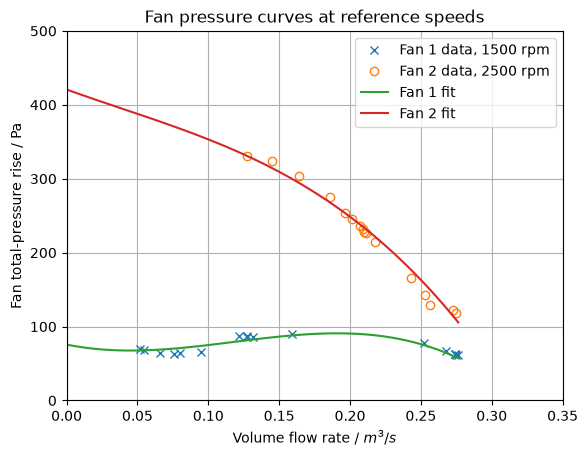

In [193]:
plt.figure()
plt.title('Fan pressure curves at reference speeds')
plt.plot(vfr_1_a, dptot_1_a, 'x', label='Fan 1 data, 1500 rpm')
plt.plot(vfr_2_a, dptot_2_a, 'o', fillstyle='none', label='Fan 2 data, 2500 rpm')
plt.plot(x_fan1, curve_fan1, label='Fan 1 fit')
plt.plot(x_fan2, curve_fan2, label='Fan 2 fit')
plt.xlabel('Volume flow rate / $m^3/s$')
plt.ylabel('Fan total-pressure rise / Pa')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.35)
plt.ylim(0, 500)
plt.show()

## 4.2 Efficiency curve

Plot both fan curves with markers ("x" and "o") in one plot.
For each fan, a fit using the provided data is already plotted which can be used to check your results. Your efficiency curves should be close to the fits!
There are some outliers...

In [194]:
# Fits created with the data in Fan_C.csv and Fan_A.csv
fit_eta_fan1 = [-3.32530612e+01,  9.91916354e+00,  2.83281874e-01,  2.82794770e-03]
x_eta_fan1 = np.linspace(0,np.max(vfr_1_a),100)
curve_eta_fan1 = fit_eta_fan1[0]*x_eta_fan1**3 + fit_eta_fan1[1]*x_eta_fan1**2 + fit_eta_fan1[2]*x_eta_fan1 + fit_eta_fan1[3]
fit_eta_fan2 = [-6.37383004e+01,  1.48112344e+01,  1.65639343e+00, -7.74093899e-03]
x_eta_fan2 = np.linspace(0,np.max(vfr_1_a),100)
curve_eta_fan2 = fit_eta_fan2[0]*x_eta_fan2**3 + fit_eta_fan2[1]*x_eta_fan2**2 + fit_eta_fan2[2]*x_eta_fan2 + fit_eta_fan2[3]

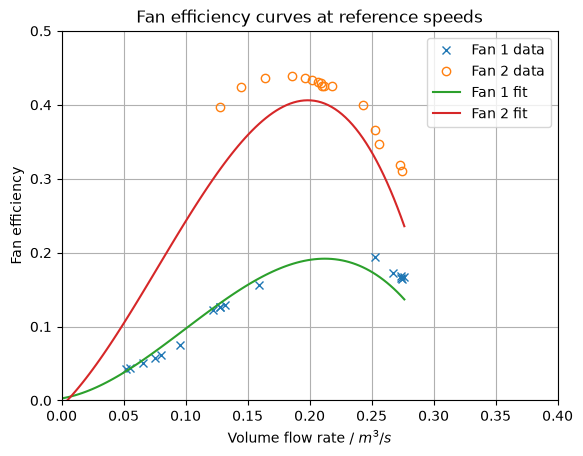

In [195]:
plt.figure()
plt.title('Fan efficiency curves at reference speeds')
plt.plot(vfr_1_a, eta_1_a, 'x', label='Fan 1 data')
plt.plot(vfr_2_a, eta_2_a, 'o', fillstyle='none', label='Fan 2 data')
plt.plot(x_eta_fan1, curve_eta_fan1, label='Fan 1 fit')
plt.plot(x_eta_fan2, curve_eta_fan2, label='Fan 2 fit')
plt.xlabel('Volume flow rate / $m^3/s$')
plt.ylabel('Fan efficiency')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.4)
plt.ylim(0, 0.5)
plt.show()

# 5. Results and Discussion

## 5.1 Evaluation of results (including error discussion) - Ergebnis- und Fehlerdiskussion**

The higher volume flow rates could not be fully investigated due to the limitation in power of the auxiliary fan.

Having the auxiliary fan on in one test and off on the other ensured that we got enough data points for the diagram

### Possible errors

Possible errors include reading/parallax errors of the liquid manometers, oscillating liquid columns, tachometer alignment, electrical-power-meter uncertainty,temperature/humidity/ambient-pressure errors, uncertainty of nozzle and fan diameters, leakage, non-uniform or swirling flow, insufficient waiting time before recording, throttle-position hysteresis and the approximation that the affinity laws and efficiency remain exact over a large speed range. Isolated outliers should be checked, not silently deleted.

# 6. Further Questions

## 6.1 Why does the pressure curve not "reach" the x-axis (why couldn't we measure ther very right part of the fan curve where the fan pressure goes to 0 Pa)?

At the right end of the fan curve the fan total-pressure rise approaches zero, but the test rig still has pressure losses in the nozzle, ducts, flow straightener, throttle and other components. A finite pressure difference is required to drive a finite flow through these resistances. The auxiliary fan can compensate part of this loss and move the operating point farther to the right, but its capacity is limited. Therefore the exact free-delivery point of the test fan cannot normally be reached on this rig.

This function takes an array of fan speeds you would like to try out an plots the resulting Pressure and efficiency curves so as to see if an adjustment of speed will allow us to reac the targets stated in sections 6.2 and 6.3.

In [196]:
target_speeds_A = [x for x in range(1000,5500,500)]
target_speeds_C = [x for x in range(1000,5500,500)]
def plot_fan_curves_at_speeds(speeds,Fan="C",target={'vfr':0.5,'p':200},vfr=vfr_1,dptot=dptot_1,P_Fluid=P_Fluid_1,P_M = P_M_1,n_measured = df1['fan_speed']):
    """Plot scaled fan curves for a Fan at the requested speeds."""
    def scale_fan1(vfr, dptot, P_Fluid, P_M, n_measured, n_target):
        valid = n_measured.notna()
        v = vfr[valid]
        d = dptot[valid]
        p = P_M[valid]
        f = P_Fluid[valid]
        scaled_v = affi_vdot(v, n_measured[valid], n_target)
        scaled_d = affi_pressure(d, n_measured[valid], n_target)
        scaled_eta = affi_power(f, n_measured[valid], n_target) / affi_power(p, n_measured[valid], n_target)
        return scaled_v, scaled_d, scaled_eta

    plt.figure(figsize=(10, 5))
    for n_target in speeds:
        v1, d1, eta1 = scale_fan1(vfr, dptot, P_Fluid, P_M, n_measured, n_target)
        plt.plot(v1, d1, marker='x', linestyle='-', label=f'Fan {Fan} @ {n_target:.0f} rpm')
    plt.title(f'Fan {Fan} total-pressure rise vs. volume flow rate')
    plt.xlabel('Volume flow rate / m^3/s')
    plt.ylabel('Fan total-pressure rise / Pa')
    plt.scatter(target['vfr'],target['p'],marker='^',color='k',label='target')
    plt.axvline(x=target['vfr'],color='k',linestyle='--')
    plt.axhline(y=target['p'],color='k',linestyle='--')
   
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    for n_target in speeds:
        v1, d1, eta1 = scale_fan1(vfr_1, dptot_1, P_Fluid_1, P_M_1, df1['fan_speed'], n_target)
        plt.plot(v1, eta1, marker='x', linestyle='-', label=f'Fan {Fan} @ {n_target:.0f} rpm')
    plt.title(f'Fan {Fan} efficiency vs. volume flow rate')
    plt.xlabel('Volume flow rate / m^3/s')
    plt.ylabel('Fan efficiency')
    plt.axvline(x=target['vfr'],color='k',linestyle='--')
    plt.grid(True)
    plt.legend()
    plt.show()

## 6.2 Application Case 1
For a given system the operation point ($\Delta p_{tot}=200 Pa$ | $\dot{V}=0.5 m^3/s$) is to be realized.</br>
Which of the two fans would you choose for this task? Give reasons for your decision!</br>
Remember, that you can adjust the revspeed of the fans freely to shift the characteristic curve of the fans!</br>
If your datset is not complete, you can use the provided dataset of fan_1 and fan_2.

We shall now test the fans at different speeds to see if they can reach the required target operating point and which fan is better for that use case.

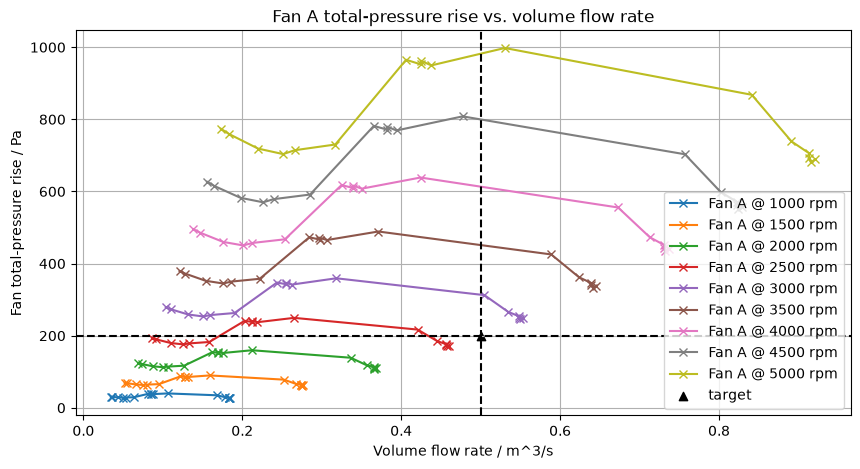

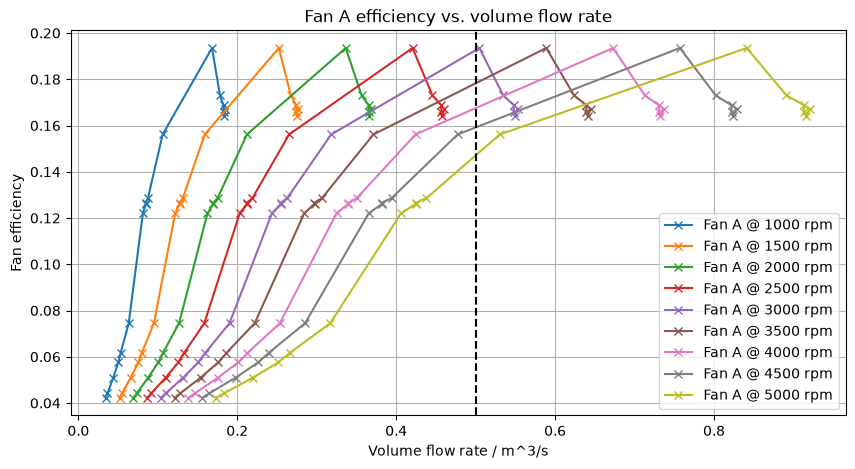

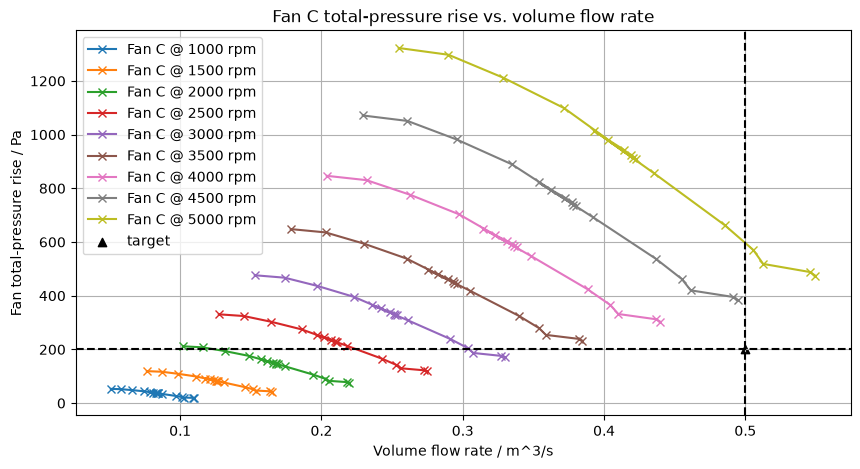

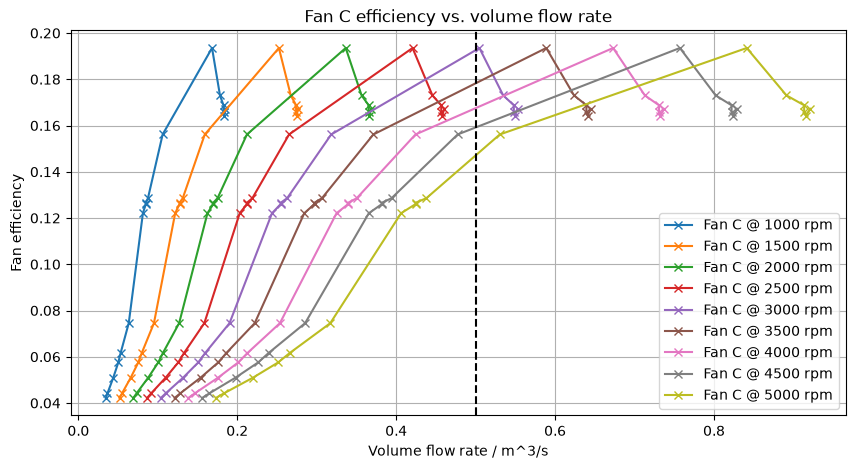

In [197]:
target = {'vfr':0.5,'p':200}
plot_fan_curves_at_speeds(target_speeds_A, "A",target={'vfr':0.5,'p':200})
plot_fan_curves_at_speeds(target_speeds_C,"C",target,vfr_2,dptot_2,P_Fluid_2,P_M_2,df2['fan_speed'])

# Conclusion
## Pick the axial fan. Because at a speed of about 2500 to 3000 rpm it arrives at the required operating point.
Despite the centrifugal fan having a higher efficiency at that speed it needs a much higher speed to reach the required operating point and thus the axial fan is a better choice. The axial fan reaches the right opertaing point at a lower speed with a similar efficiency.

## 6.3 Application Case 2
For another system, the operation point ($\Delta p_{tot}=200 Pa$ | $\dot{V}=0.1 m^3/s$) is to be realized.</br>
Which of the fans do you select? Give reasons for your decision.</br>
Remember that you can adjust the revspeed of the fans freely to shift the characteristic curve of the fans!

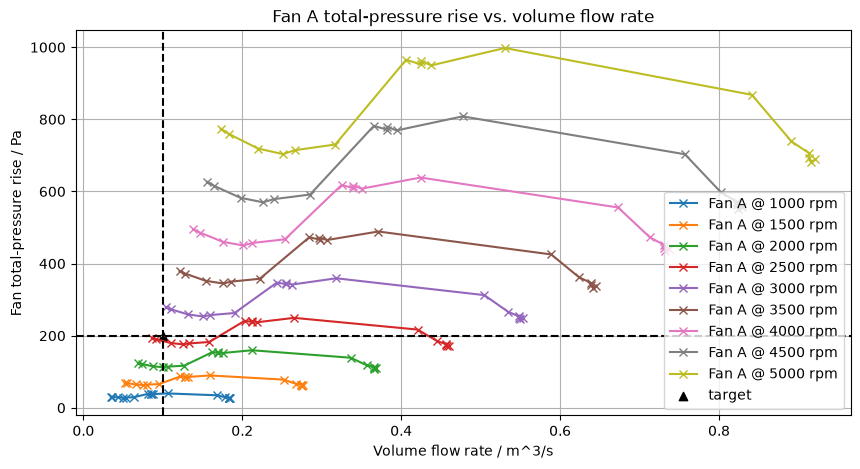

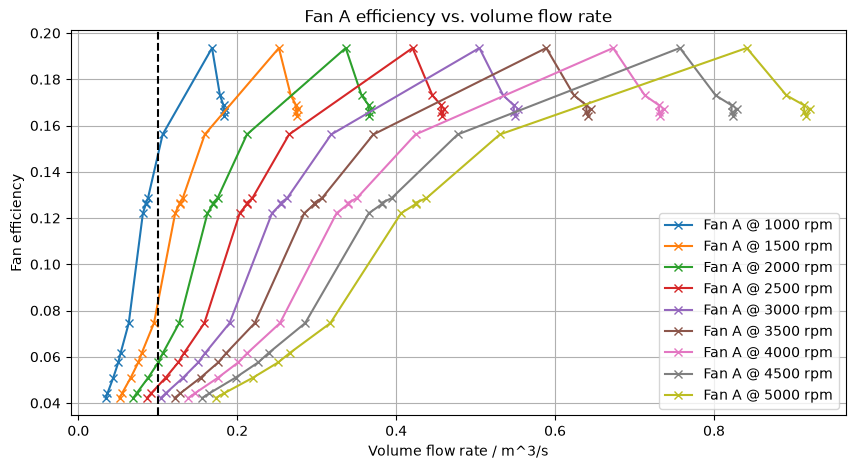

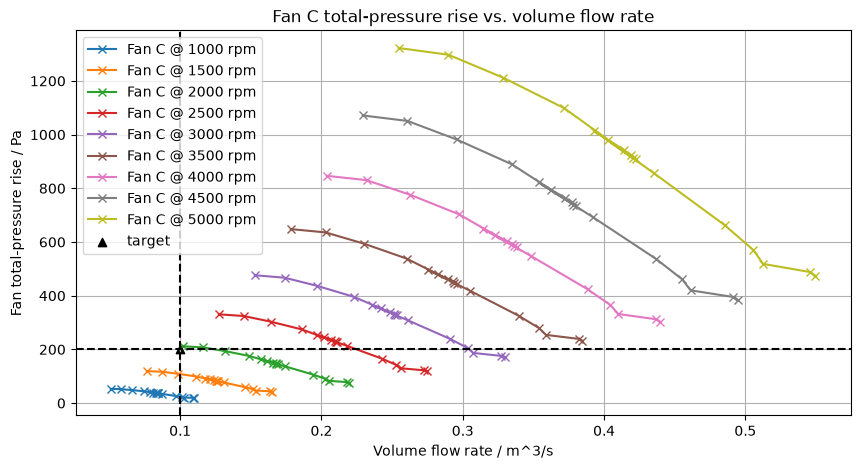

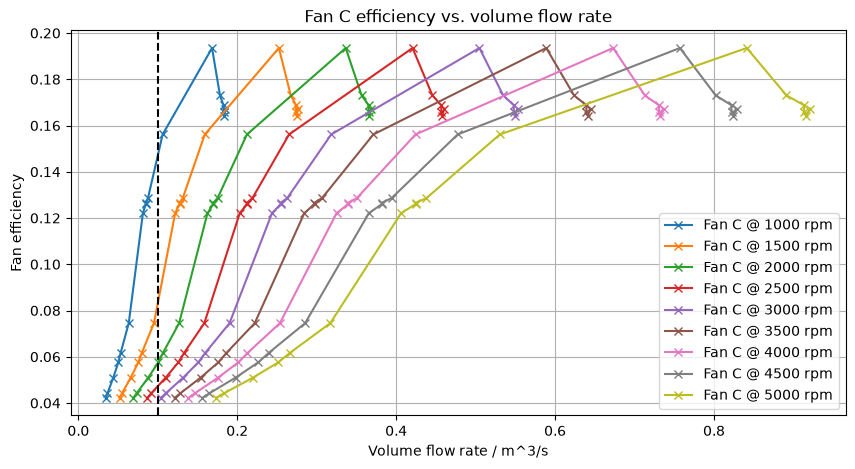

In [198]:
target = {'vfr':0.1,'p':200}
plot_fan_curves_at_speeds(target_speeds_A, "A",target)
plot_fan_curves_at_speeds(target_speeds_C,"C",target,vfr_2,dptot_2,P_Fluid_2,P_M_2,df2['fan_speed'])

# Conclusion
## The centrifugal fan reaches the target operating point with the highest efficiency and lowest speed necessary and should be used for this application.